# The (412) Index: Best Neighborhood in Pittsburgh for Young Adults

## Introduction

For our final project, we wanted to figure out **what the best neighborhood in Pittsburgh is for young adults**. As college students living in Pittsburgh, we thought about what matters most to someone our age when picking a place to live. We came up with three things:

1. **Safety** because you want to feel safe where you live.
2. **Nightlife** because having restaurants and bars nearby is a major part of young adult life.
3. **Affordability** since as adults right out of college, budget will be a major factor of living

We used datasets from the [Western Pennsylvania Regional Data Center (WPRDC)](https://data.wprdc.org/) to measure each of these.

### Team Members

- [MEMBER 1 NAME] ([EMAIL]) — [METRIC THEY DID]
- [MEMBER 2 NAME] ([EMAIL]) — [METRIC THEY DID]

### Datasets Used

| Metric | Dataset | Source |
|---|---|---|
| Safety | Pittsburgh Police Arrest Data | WPRDC |
| Nightlife | Allegheny County Food Facility Inspections | WPRDC |
| Affordability | Allegheny County Property Assessments | WPRDC |

## The Metric

We created a combined score called the **(412) Index**. Here's how it works:

Each sub-metric is scored from 0 to 1 using **min-max normalization**. For safety and affordability, we **inverted** the scores so that lower crime and lower property values give a higher score (which is what a young adult would want).

Then we combined them with these weights:

- **Safety: 40%** — This is the most important because feeling safe is a basic need.
- **Nightlife: 30%** — Young adults want things to do nearby.
- **Affordability: 30%** — They'd need to be able to actually afford to live there.

**Formula:**

`(412) Index = (safety_score × 0.4) + (nightlife_score × 0.3) + (affordability_score × 0.3)`

## Analysis

Let's load in the scores from each team member's individual notebook and combine them.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
nightlife = pd.read_csv("scores/nightlife_scores.csv")
safety = pd.read_csv("scores/safety_scores.csv")
affordability = pd.read_csv("scores/affordability_scores.csv")

# lets see what columns each file has
print("Nightlife columns:", list(nightlife.columns))
print("Safety columns:", list(safety.columns))
print("Affordability columns:", list(affordability.columns))

Nightlife columns: ['neighborhood', 'nightlife_score']
Safety columns: ['neighborhood', 'safety_score']
Affordability columns: ['neighborhood', 'affordability_score']


In [ ]:

nightlife.columns = ["neighborhood", "nightlife_score"]
safety.columns = ["neighborhood", "safety_score"]
affordability.columns = ["neighborhood", "affordability_score"]


nightlife["neighborhood"] = nightlife["neighborhood"].str.strip().str.upper()
safety["neighborhood"] = safety["neighborhood"].str.strip().str.upper()
affordability["neighborhood"] = affordability["neighborhood"].str.strip().str.upper()

In [ ]:
print("--- Nightlife Scores ---")
print(nightlife.head())
print()
print("--- Safety Scores ---")
print(safety.head())
print()
print("--- Affordability Scores ---")
print(affordability.head())

--- Nightlife Scores ---
     neighborhood  nightlife_score
0  STRIP DISTRICT         1.000000
1         OAKLAND         0.915094
2      NORTH SIDE         0.910377
3        WESTWOOD         0.693396
4   SQUIRREL HILL         0.688679

--- Safety Scores ---
              neighborhood  safety_score
0  MT. OLIVER NEIGHBORHOOD      1.000000
1   TROY HILL-HERRS ISLAND      0.999099
2          MT. OLIVER BORO      0.996395
3        CENTRAL NORTHSIDE      0.995268
4            REGENT SQUARE      0.992114

--- Affordability Scores ---
             neighborhood  affordability_score
0  CLOVERLEAF MOBILE H.P.             1.000000
1      JONES  MOBILE H.P.             0.999062
2                   10404             0.998660
3  ROSENBERRY MOBILE H.P.             0.996918
4                   11203             0.996382


### Merging the Scores

Now we merge all three dataframes together on the neighborhood name. We use an **outer join** so we don't accidentally lose any neighborhoods. If a neighborhood is missing a score, we'll just fill it with 0.

In [ ]:
combined = nightlife.merge(safety, on="neighborhood", how="outer")
combined = combined.merge(affordability, on="neighborhood", how="outer")

combined = combined.fillna(0)

print(f"We have scores for {len(combined)} neighborhoods")
combined.head(10)

We have scores for 253 neighborhoods


,neighborhood,nightlife_score,safety_score,affordability_score
0,1000 GRANDVIEW,0.0,0.0,0.546593
1,10401,0.0,0.0,0.366919
2,10402,0.0,0.0,0.931132
3,10403,0.0,0.0,0.895491
4,10404,0.0,0.0,0.998660
5,10501,0.0,0.0,0.816038
6,10502,0.0,0.0,0.883332
7,10503,0.0,0.0,0.970389
8,10601,0.0,0.0,0.915589
9,10801,0.0,0.0,0.803711


### Calculating the (412) Index

Now we apply our weighted formula to get the final score for each neighborhood.

In [ ]:
combined["(412)_index"] = (
    combined["safety_score"] * 0.4 +
    combined["nightlife_score"] * 0.3 +
    combined["affordability_score"] * 0.3
)

combined = combined.sort_values("(412)_index", ascending=False)
combined = combined.reset_index(drop=True)

combined.head(10)

,neighborhood,nightlife_score,safety_score,affordability_score,(412)_index
0,STRIP DISTRICT,1.000000,0.887111,0.000000,0.654845
1,WESTWOOD,0.693396,0.949527,0.000000,0.587830
2,SHADYSIDE,0.221698,0.781658,0.573926,0.551351
3,BROOKLINE,0.533019,0.687247,0.000000,0.434804
4,BLOOMFIELD,0.377358,0.778729,0.000000,0.424699
5,EAST LIBERTY,0.632075,0.574808,0.000000,0.419546
6,CRAFTON HEIGHTS,0.235849,0.865029,0.000000,0.416766
7,POINT BREEZE,0.141509,0.932627,0.000000,0.415504
8,MT. OLIVER NEIGHBORHOOD,0.000000,1.000000,0.000000,0.400000
9,TROY HILL-HERRS ISLAND,0.000000,0.999099,0.000000,0.399639


## The Best Neighborhood

Let's visualize the top 15 neighborhoods and see which one came out on top.

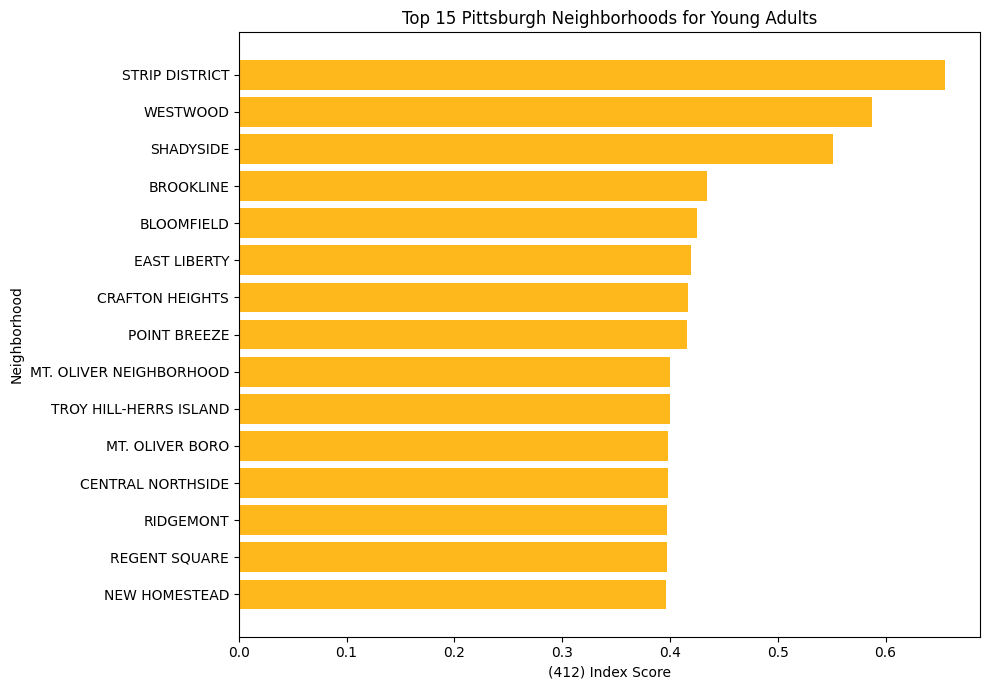

In [ ]:
top15 = combined.head(15)

plt.figure(figsize=(10, 7))
plt.barh(top15["neighborhood"], top15["(412)_index"], color="#FFB81C")
plt.xlabel("(412) Index Score")
plt.ylabel("Neighborhood")
plt.title("Top 15 Pittsburgh Neighborhoods for Young Adults")
plt.gca().invert_yaxis()   
plt.tight_layout()
plt.show()

In [ ]:
best = combined.iloc[0]
print(f"The best neighborhood for young adults in Pittsburgh is: {best['neighborhood']}")
print(f"\n(412) Index Score: {best['(412)_index']:.3f}")
print(f"  Safety Score:       {best['safety_score']:.3f}")
print(f"  Nightlife Score:    {best['nightlife_score']:.3f}")
print(f"  Affordability Score: {best['affordability_score']:.3f}")

The best neighborhood for young adults in Pittsburgh is: STRIP DISTRICT

(412) Index Score: 0.655
  Safety Score:       0.887
  Nightlife Score:    1.000
  Affordability Score: 0.000


### Breakdown of the Top 5

Let's also look at how the top 5 neighborhoods compare across all three sub-metrics.

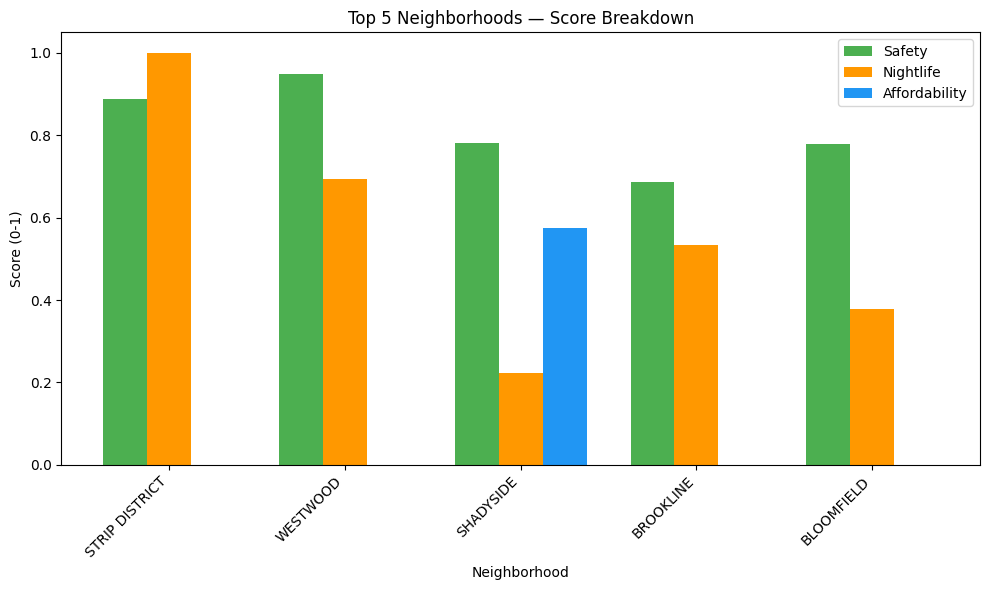

In [ ]:
top5 = combined.head(5)

fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(top5))
width = 0.25

ax.bar([i - width for i in x], top5["safety_score"], width, label="Safety", color="#4CAF50")
ax.bar(x, top5["nightlife_score"], width, label="Nightlife", color="#FF9800")
ax.bar([i + width for i in x], top5["affordability_score"], width, label="Affordability", color="#2196F3")

ax.set_xlabel("Neighborhood")
ax.set_ylabel("Score (0-1)")
ax.set_title("Top 5 Neighborhoods — Score Breakdown")
ax.set_xticks(x)
ax.set_xticklabels(top5["neighborhood"], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

Based on our analysis the data shows that Strip District is the best neighborhood in Pittsburgh for young adults. It scored well across safety, nightlife, and affordability, which are the three things we think matter most when you're young and looking for a place to live in the city.

---

### Individual Conclusions

**Darsh's Conclusion:**
What i personally think about the final result is that, some of the data that got messed up, due to it not having a similar result/column in the other data tables. i would go with SHADYSIDE for being the best neighbourhood as it has visible proof on what the results are, and we would not just be guessing the other missing data on our own. 



**Nick's Conclusion:**

The Strip District, surprisingly has the best mix of safety, nightlife, and affordibility. Though our knowledge of Pittsburgh is very limited, this was still suprrising because the area is nice, but I would not say that it is noticably safe, affordible, or has outstanding nightlife (though I will say that it if anything the Strip District has a lot of food or market options to an outsider). However, in looking at this result as an outsider and how it may seem underwhelming, that may speak to our data and how we averaged it. Yes, we wanted the average of three different metrics, but since these are three relatively unrelated categories, it makes sense that the "best" neighborhood is one that we may not have expected, as it seems like more of an "average" neighborhood as an outsider.